In [1]:
import HTSeq
import numpy as np

from price2.cleavage_model import CleavageModel
from price2.reference_annotation import ReferenceAnnotation
from price2.rgr_finder import RGRFinder

from orf_activity_estimator import ORFActivityEstimator

from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
# steps:
# load annotation (only transcript information)
# generate loci with compatibility groups
# iterate over reads assign them to compatibility groups and association groups
# iterate over loci and estimate activity

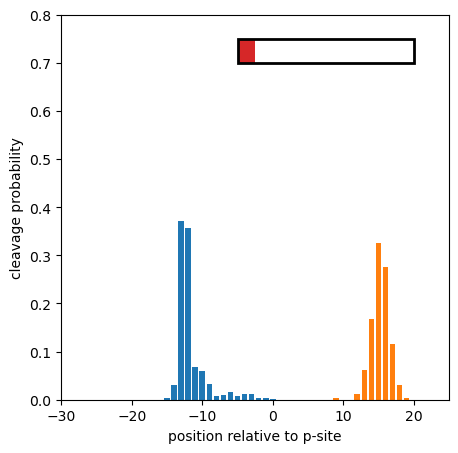

In [3]:
pl = np.loadtxt('/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/upstream_cleavage_model')
pl = pl / pl.sum()
pr = np.loadtxt('/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/downstream_cleavage_model')
pr = pr / pr.sum()
u = .1
cm = CleavageModel(pl, pr, u)

def plot_cleavage_model(cm, axs):
    axs.bar(range(-len(cm.pl)+1,1),cm.pl[::-1])
    axs.bar(range(len(cm.pr)),cm.pr)
    axs.set_xlim(-30,25)
    axs.set_ylim(0, .8)
    fill = Rectangle((-5, .7), cm.pu*25, .05, fill=True, facecolor='tab:red')
    frame = Rectangle((-5, .7), 25, .05, fill=False, edgecolor='black', linewidth=2)
    axs.add_patch(fill)
    axs.add_patch(frame)
    axs.set_xlabel('position relative to p-site')
    axs.set_ylabel('cleavage probability')

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plot_cleavage_model(cm, ax)

In [4]:
gtf_path = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/orf_deconvolution.gtf'
fasta_path = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/orf_deconvolution.fasta'

#gtf_path = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/test/test.gtf'
#fasta_path = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/test/test.fasta'

ra = ReferenceAnnotation(gtf_path)
genome = dict((s.name, s) for s in HTSeq.FastaReader(fasta_path))

In [5]:
rgr_finder = RGRFinder(ra.transcripts, genome)

In [6]:
oae = ORFActivityEstimator(
    cm,
    ra,
    rgr_finder,
    '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/simulated_reads_advanced.sam',
)

#oae = ORFActivityEstimator(
#    cm,
#    ra,
#    of,
#    '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/test/test.sam',
#)

In [7]:
oae.fill_groups()
oae.total_read_count

AttributeError: 'ORFActivityEstimator' object has no attribute 'loci_intervals'

In [ ]:
list(oae.loci_set)[0].association_groups

{(frozenset({(NOISE on region chr2:+:[999,2100):[2999,5000), None),
             (NOISE on region chr2:+:[999,5000), None),
             (ORF on region chr2:+:[1301,2100):[2999,3400), 2),
             (ORF on region chr2:+:[1301,4700), 2)}),
  32,
  False): <orf_activity_estimator.AssociationGroup at 0x7faf87287730>,
 (frozenset({(NOISE on region chr2:+:[999,2100):[2999,5000), None),
             (NOISE on region chr2:+:[999,5000), None),
             (ORF on region chr2:+:[1301,2100):[2999,3400), 2),
             (ORF on region chr2:+:[1301,4700), 2)}),
  27,
  False): <orf_activity_estimator.AssociationGroup at 0x7faf87286c50>,
 (frozenset({(NOISE on region chr2:+:[999,2100):[2999,5000), None),
             (NOISE on region chr2:+:[999,5000), None),
             (ORF on region chr2:+:[1301,2100):[2999,3400), 0),
             (ORF on region chr2:+:[1301,4700), 2)}),
  32,
  False): <orf_activity_estimator.AssociationGroup at 0x7faf872874f0>,
 (frozenset({(NOISE on region chr2:+:[999,5

In [ ]:
from price2.ribo_seq_alignment import RiboSeqAlignment
reader = HTSeq.BAM_Reader('/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/simulated_reads_advanced.sam')
for read in reader:
    read_al = RiboSeqAlignment(read)
    break
read
oae.rgr_finder.collect_rgrs(read_al.genomic_region)

{NOISE on region chr2:+:[999,2100):[2999,5000),
 NOISE on region chr2:+:[999,5000),
 ORF on region chr2:+:[1301,2100):[2999,3400),
 ORF on region chr2:+:[1301,4700)}

In [ ]:
list(oae.rgr_finder.rgr_intervals.steps())

[(<GenomicInterval object 'chr1', [0,999), strand '+'>, set()),
 (<GenomicInterval object 'chr1', [999,1101), strand '+'>,
  {NOISE on region chr1:+:[999,2000)}),
 (<GenomicInterval object 'chr1', [1101,1147), strand '+'>,
  {NOISE on region chr1:+:[999,2000), ORF on region chr1:+:[1101,1200)}),
 (<GenomicInterval object 'chr1', [1147,1200), strand '+'>,
  {NOISE on region chr1:+:[999,2000),
   ORF on region chr1:+:[1101,1200),
   ORF on region chr1:+:[1147,1348)}),
 (<GenomicInterval object 'chr1', [1200,1299), strand '+'>,
  {NOISE on region chr1:+:[999,2000), ORF on region chr1:+:[1147,1348)}),
 (<GenomicInterval object 'chr1', [1299,1348), strand '+'>,
  {NOISE on region chr1:+:[999,2000),
   ORF on region chr1:+:[1147,1348),
   ORF on region chr1:+:[1299,1950)}),
 (<GenomicInterval object 'chr1', [1348,1600), strand '+'>,
  {NOISE on region chr1:+:[999,2000), ORF on region chr1:+:[1299,1950)}),
 (<GenomicInterval object 'chr1', [1600,1701), strand '+'>,
  {NOISE on region chr1:+:[

In [ ]:
from time import time

for loc in oae.loci_set:
    time_start = time()
    loc.run_orf_deconvolution(1000, .005, oae.cm)
    time_end = time()
    print(f'orf deconvolution took: {time_end - time_start:.2f}s')


break at iteration 190
orf deconvolution took: 1.04s
break at iteration 39
orf deconvolution took: 0.15s
break at iteration 26
orf deconvolution took: 0.04s
break at iteration 176
orf deconvolution took: 2.42s


In [ ]:
################## plot results #####################

orf_gtf = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/orf_deconvolution_ORFs.gtf'
gtf = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/orf_deconvolution.gtf'
from price2.genomic_region import GenomicRegion

class PlotRGR:
    type: str
    genomic_region: GenomicRegion
    activity: float

    def __init__(self, type, activity, chrom, strand):
        self.type = type
        self.activity = activity
        self.genomic_region = GenomicRegion([], chrom, strand)

ground_truth_rgrs = {}

for orf in HTSeq.GFF_Reader(orf_gtf):
    if not orf.attr['ID'] in ground_truth_rgrs:
        ground_truth_rgrs[orf.attr['ID']] = PlotRGR(
            'ORF',
            int(orf.attr['activity']),
            orf.iv.chrom,
            orf.iv.strand,
            )

    ground_truth_rgrs[orf.attr['ID']].genomic_region.add_interval(orf.iv)

for region in HTSeq.GFF_Reader(gtf):
    if region.type != 'exon' and region.type != 'transcript':
        continue
    if region.type == 'transcript':
        if not region.attr['transcript_id'] in ground_truth_rgrs:
            ground_truth_rgrs[region.attr['transcript_id']] = PlotRGR(
                'NOISE',
                int(region.attr['activity']),
                region.iv.chrom,
                region.iv.strand,
                )
    if region.type == 'exon':
        ground_truth_rgrs[region.attr['transcript_id']].genomic_region.add_interval(region.iv)




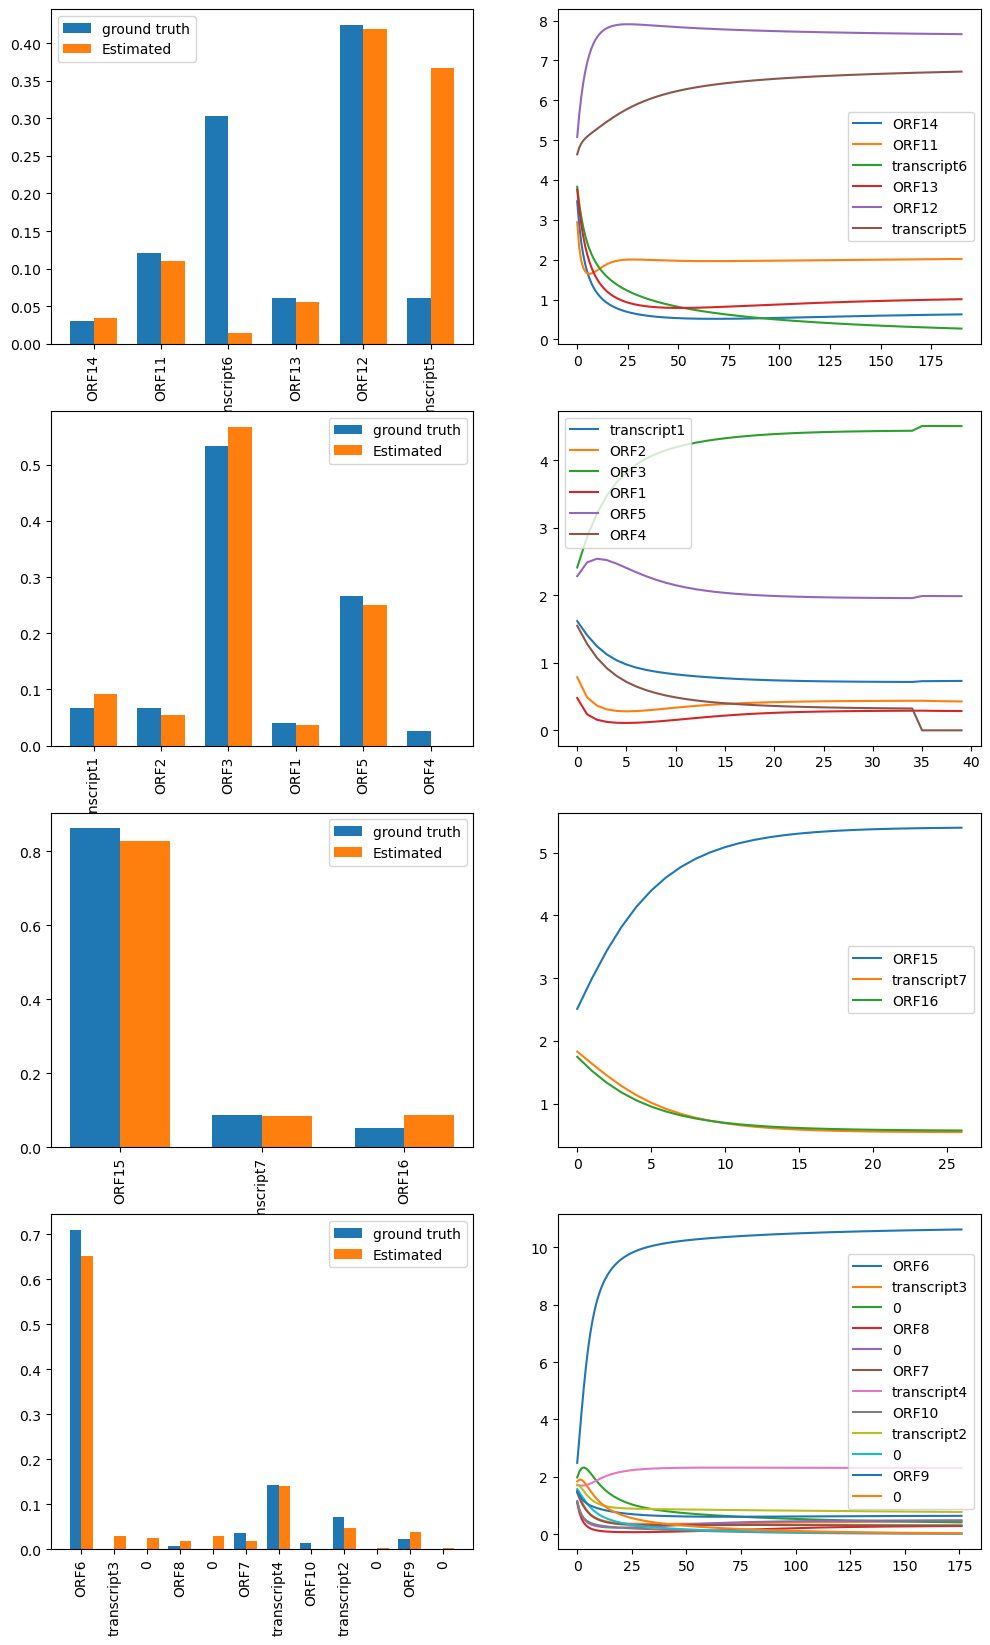

In [ ]:
fig, axs = plt.subplots(len(oae.loci_set), 2, figsize=(12, 5*len(oae.loci_set)))


loci_list = list(oae.loci_set)
for i in range(len(loci_list)):
    ids = []
    true_activities = []
    estimated_activities = []
    activity_progression = []

    for region in loci_list[i].regions:
        estimated_activities.append(region.activity)
        for id, rgr in ground_truth_rgrs.items():
            if rgr == region:
                true_activities.append(rgr.activity)
                ids.append(id)
                break
        if len(true_activities) < len(estimated_activities):
            true_activities.append(0)
            ids.append('0')

        axs[i,1].plot(loci_list[i].region_activities[region], label=ids[-1])
    axs[i,1].legend()
        

    estimated_activities = np.array(estimated_activities)
    estimated_activities = estimated_activities / estimated_activities.sum()
    true_activities = np.array(true_activities)
    true_activities = true_activities / true_activities.sum()

    bar_width = 0.35

    axs[i,0].bar([x-bar_width/2 for x in range(1,len(true_activities)+1)], true_activities, width=bar_width, label='ground truth')
    axs[i,0].bar([x+bar_width/2 for x in range(1,len(true_activities)+1)], estimated_activities, width=bar_width, label='Estimated')
    axs[i,0].legend()
    axs[i,0].set_xticks([x for x in range(1,len(true_activities)+1)], ids)
    for tick in axs[i,0].get_xticklabels():
        tick.set_rotation(90)



